# Explainable AI (SHAP)


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

# Load final model and data
final_model = joblib.load('../models/final_model.pkl')
df = pd.read_csv('../data/featured_churn.csv')

X = df.drop(columns=['Churn'])
y = df['Churn']

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

scaler     = joblib.load('../models/scaler.pkl')
scale_cols = joblib.load('../models/scale_cols.pkl')

X_train_sm[scale_cols] = scaler.transform(X_train_sm[scale_cols])
X_test[scale_cols]     = scaler.transform(X_test[scale_cols])

print("Data ready.")
print(f"Test set shape: {X_test.shape}")

c:\Users\Dw\.conda\envs\pyspark_310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Data ready.
Test set shape: (1407, 22)


In [8]:
explainer = shap.TreeExplainer(final_model)

X_test_sample = X_test.sample(500, random_state=42).reset_index(drop=True)
shap_values   = explainer.shap_values(X_test_sample)

# Diagnostic — check what shap_values looks like
print(f"Type        : {type(shap_values)}")

if isinstance(shap_values, list):
    print(f"List length : {len(shap_values)}")
    print(f"Shape [0]   : {np.array(shap_values[0]).shape}")
    print(f"Shape [1]   : {np.array(shap_values[1]).shape}")
    shap_churn = shap_values[1]
elif isinstance(shap_values, np.ndarray):
    print(f"Array shape : {shap_values.shape}")
    if shap_values.ndim == 3:
        # New SHAP format: (n_samples, n_features, n_classes)
        shap_churn = shap_values[:, :, 1]
    else:
        shap_churn = shap_values
else:
    # Explanation object
    shap_churn = shap_values.values
    if shap_churn.ndim == 3:
        shap_churn = shap_churn[:, :, 1]

print(f"\nFinal shap_churn shape : {shap_churn.shape}")
print(f"X_test_sample shape    : {X_test_sample.shape}")
assert shap_churn.shape == X_test_sample.shape, "Shape mismatch!"
print("✅ Shapes match — ready to plot.")

Type        : <class 'numpy.ndarray'>
Array shape : (500, 22, 2)

Final shap_churn shape : (500, 22)
X_test_sample shape    : (500, 22)
✅ Shapes match — ready to plot.


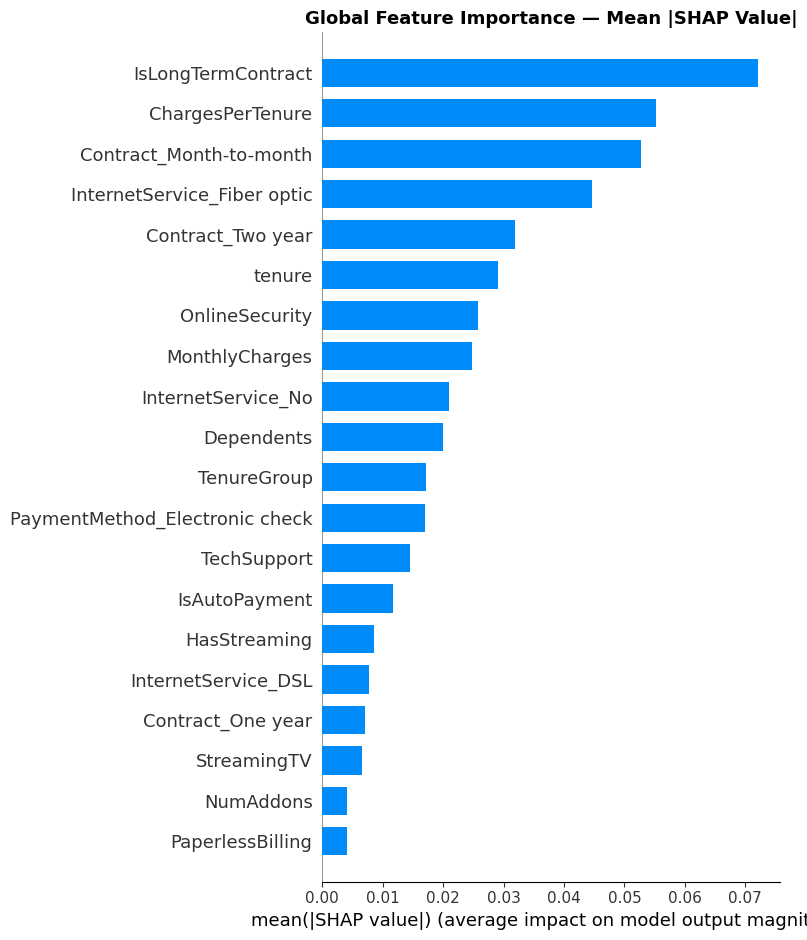

✅ Saved: 15_shap_global_importance.png


In [18]:
shap.summary_plot(
    shap_churn,
    X_test_sample,
    plot_type='bar',
    max_display=20,
    show=False
)
plt.title('Global Feature Importance — Mean |SHAP Value|',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/15_shap_global_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: 15_shap_global_importance.png")

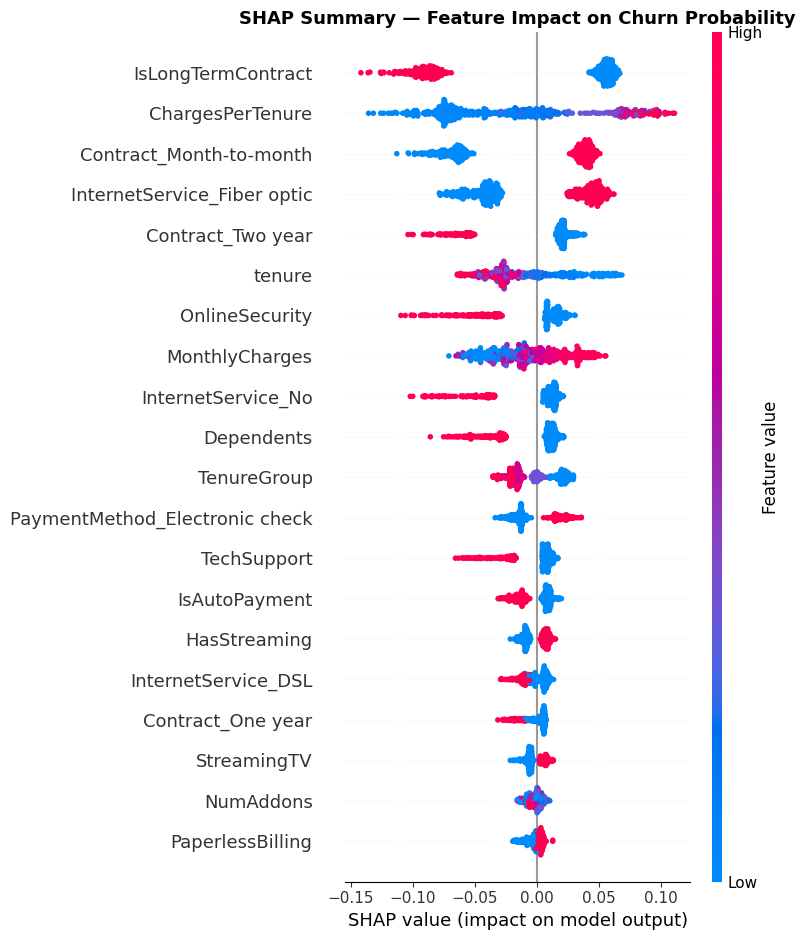

✅ Saved: 16_shap_summary_dot.png


In [19]:
# Cell 4 — Dot Summary Plot
shap.summary_plot(
    shap_churn,
    X_test_sample,
    max_display=20,
    show=False
)
plt.title('SHAP Summary — Feature Impact on Churn Probability',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/16_shap_summary_dot.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: 16_shap_summary_dot.png")

In [20]:
# Mean absolute SHAP value per feature
mean_shap = np.abs(shap_churn).mean(axis=0)
shap_df = pd.DataFrame({
    'Feature'   : X_test_sample.columns,
    'SHAP_Score': mean_shap
}).sort_values('SHAP_Score', ascending=False).reset_index(drop=True)

print("=== TOP 20 FEATURES BY SHAP IMPORTANCE ===")
print(shap_df.head(20).to_string(index=False))

# Save for research paper
shap_df.to_csv('../outputs/shap_feature_importance.csv', index=False)

=== TOP 20 FEATURES BY SHAP IMPORTANCE ===
                       Feature  SHAP_Score
            IsLongTermContract    0.072136
              ChargesPerTenure    0.055243
       Contract_Month-to-month    0.052698
   InternetService_Fiber optic    0.044649
             Contract_Two year    0.031815
                        tenure    0.029138
                OnlineSecurity    0.025786
                MonthlyCharges    0.024726
            InternetService_No    0.020906
                    Dependents    0.019951
                   TenureGroup    0.017211
PaymentMethod_Electronic check    0.016942
                   TechSupport    0.014451
                 IsAutoPayment    0.011748
                  HasStreaming    0.008606
           InternetService_DSL    0.007797
             Contract_One year    0.007128
                   StreamingTV    0.006514
                     NumAddons    0.004157
              PaperlessBilling    0.004056


In [21]:
print("""
=== BUSINESS INTERPRETATION OF SHAP RESULTS ===

1. tenure
   → Low tenure = high SHAP toward churn
   → New customers are highest risk
   → Action: Intensive onboarding in first 12 months

2. Contract_Month-to-month
   → Month-to-month contract strongly pushes toward churn
   → No long-term commitment = easy to leave
   → Action: Incentivize annual/biennial contract upgrades

3. MonthlyCharges
   → High monthly charges increase churn probability
   → Customers feel they overpay relative to value
   → Action: Offer loyalty discounts to high-charge customers

4. InternetService_Fiber optic
   → Fiber optic users churn more despite premium service
   → Likely: high cost + competition + unmet expectations
   → Action: Improve fiber service quality and perceived value

5. NumAddons / OnlineSecurity / TechSupport
   → Fewer add-ons = higher churn SHAP
   → Add-ons create switching cost and engagement
   → Action: Upsell security and support packages

6. IsLongTermContract
   → Long-term contract strongly reduces churn SHAP
   → Confirms contract type is primary retention lever
   → Action: Make contract upgrade offers prominent

7. ChargesPerTenure
   → High early charges relative to tenure = churn risk
   → New customers paying premium feel undervalued
   → Action: Introductory pricing for new customers
""")


=== BUSINESS INTERPRETATION OF SHAP RESULTS ===

1. tenure
   → Low tenure = high SHAP toward churn
   → New customers are highest risk
   → Action: Intensive onboarding in first 12 months

2. Contract_Month-to-month
   → Month-to-month contract strongly pushes toward churn
   → No long-term commitment = easy to leave
   → Action: Incentivize annual/biennial contract upgrades

3. MonthlyCharges
   → High monthly charges increase churn probability
   → Customers feel they overpay relative to value
   → Action: Offer loyalty discounts to high-charge customers

4. InternetService_Fiber optic
   → Fiber optic users churn more despite premium service
   → Likely: high cost + competition + unmet expectations
   → Action: Improve fiber service quality and perceived value

5. NumAddons / OnlineSecurity / TechSupport
   → Fewer add-ons = higher churn SHAP
   → Add-ons create switching cost and engagement
   → Action: Upsell security and support packages

6. IsLongTermContract
   → Long-term co

Highest risk index    : 326
Churn probability     : 0.9419


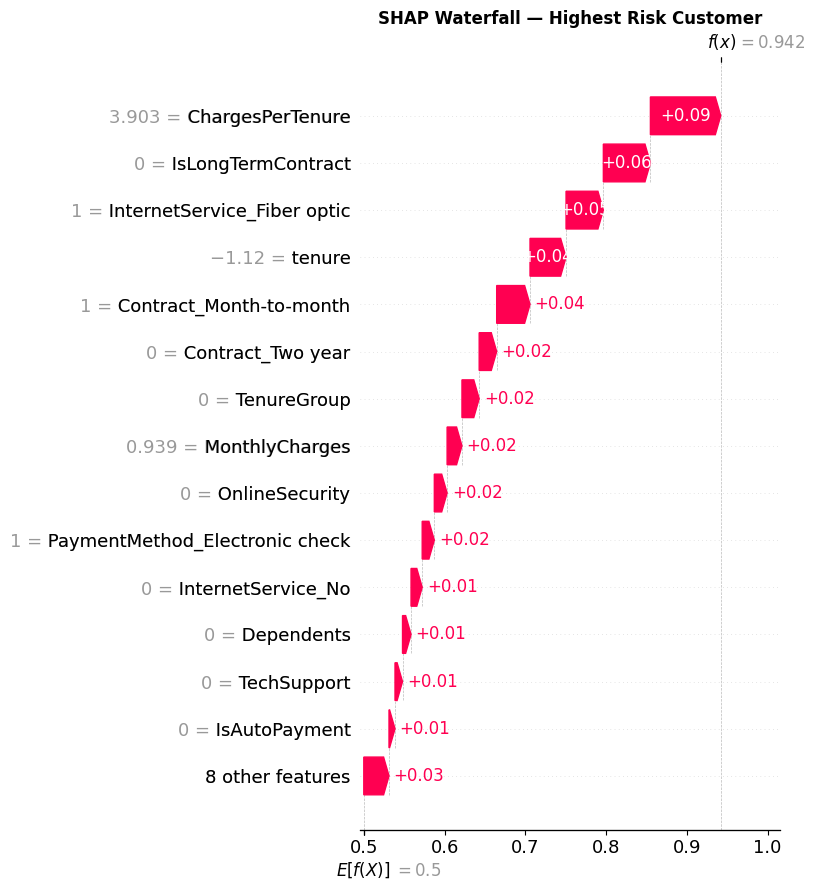

✅ Saved: 17_shap_waterfall_highrisk.png


In [22]:

probs         = final_model.predict_proba(X_test_sample)[:, 1]
high_risk_idx = int(np.argmax(probs))

print(f"Highest risk index    : {high_risk_idx}")
print(f"Churn probability     : {probs[high_risk_idx]:.4f}")

# Handle expected_value for binary classifier
base_val = (explainer.expected_value[1]
            if isinstance(explainer.expected_value, (list, np.ndarray))
            else explainer.expected_value)

shap_exp = shap.Explanation(
    values        = shap_churn[high_risk_idx],
    base_values   = base_val,
    data          = X_test_sample.iloc[high_risk_idx].values,
    feature_names = X_test_sample.columns.tolist()
)

shap.waterfall_plot(shap_exp, max_display=15, show=False)
plt.title('SHAP Waterfall — Highest Risk Customer', fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/17_shap_waterfall_highrisk.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: 17_shap_waterfall_highrisk.png")

Lowest risk index     : 354
Churn probability     : 0.0056


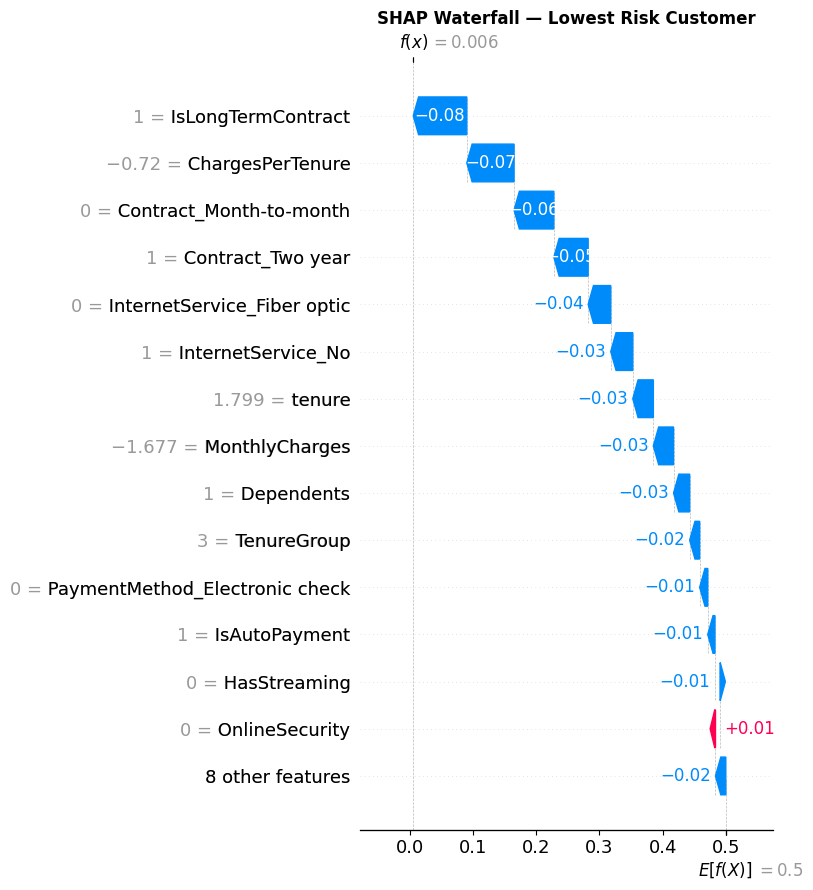

✅ Saved: 18_shap_waterfall_lowrisk.png


In [23]:
# Cell 8 — Waterfall Low Risk
low_risk_idx = int(np.argmin(probs))

print(f"Lowest risk index     : {low_risk_idx}")
print(f"Churn probability     : {probs[low_risk_idx]:.4f}")

shap_exp_low = shap.Explanation(
    values        = shap_churn[low_risk_idx],
    base_values   = base_val,
    data          = X_test_sample.iloc[low_risk_idx].values,
    feature_names = X_test_sample.columns.tolist()
)

shap.waterfall_plot(shap_exp_low, max_display=15, show=False)
plt.title('SHAP Waterfall — Lowest Risk Customer', fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/18_shap_waterfall_lowrisk.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: 18_shap_waterfall_lowrisk.png")

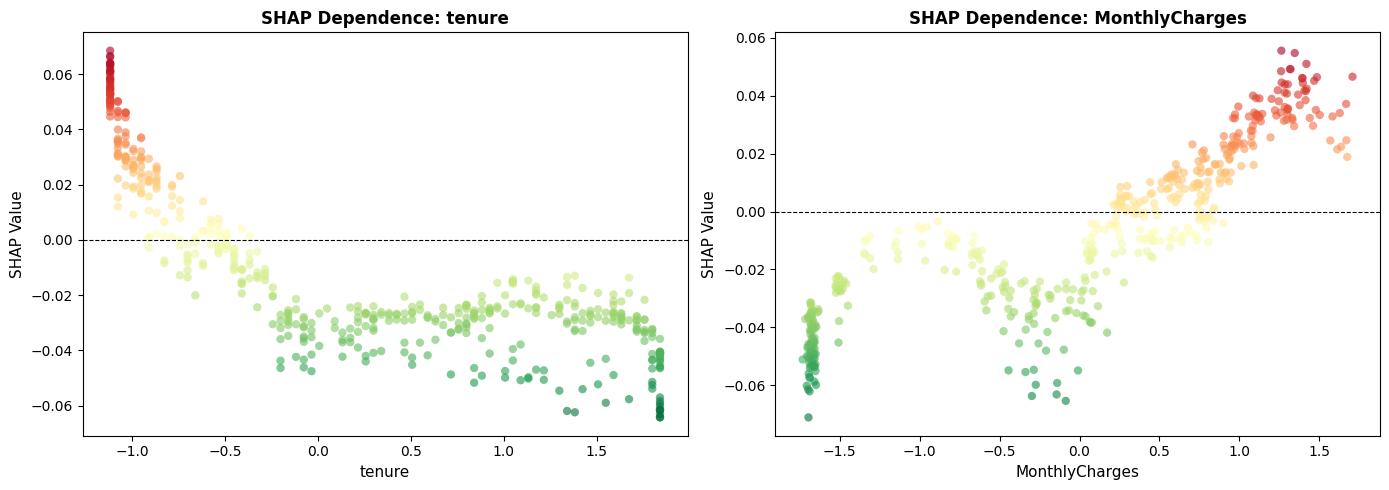

✅ Saved: 19_shap_dependence.png


In [24]:
# Cell 9 — Fixed for new SHAP format
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

feature_list = list(X_test_sample.columns)
tenure_idx   = feature_list.index('tenure')
charges_idx  = feature_list.index('MonthlyCharges')

for ax, (feat, idx) in zip(axes, [('tenure', tenure_idx),
                                   ('MonthlyCharges', charges_idx)]):
    ax.scatter(
        X_test_sample.iloc[:, idx].values,
        shap_churn[:, idx],
        c=shap_churn[:, idx],
        cmap='RdYlGn_r',
        alpha=0.6,
        edgecolors='none'
    )
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel(feat, fontsize=11)
    ax.set_ylabel('SHAP Value', fontsize=11)
    ax.set_title(f'SHAP Dependence: {feat}', fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/19_shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: 19_shap_dependence.png")

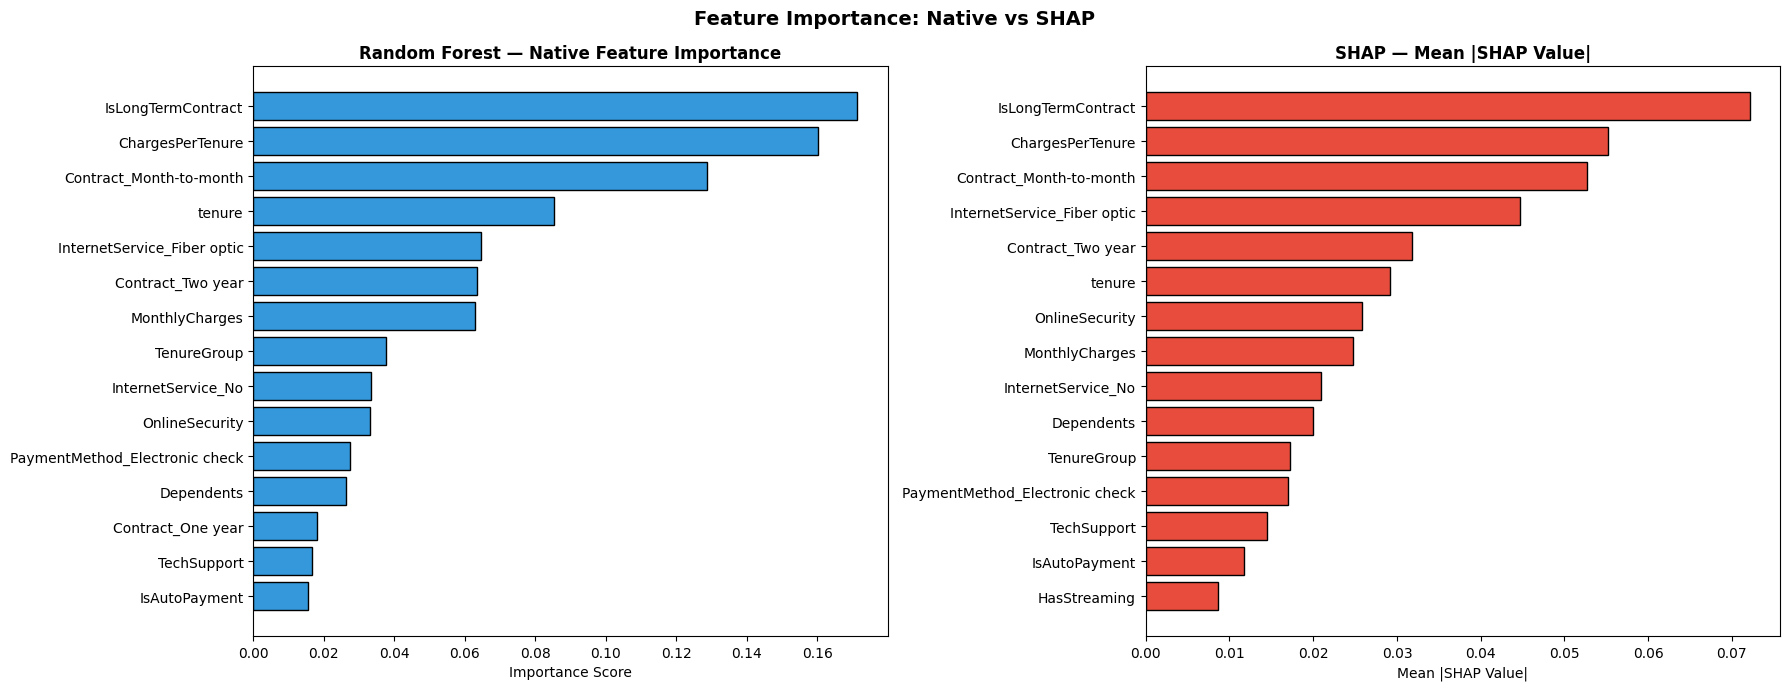

Top 10 RF Native Importance:
                    Feature  RF_Importance
         IsLongTermContract       0.171332
           ChargesPerTenure       0.160250
    Contract_Month-to-month       0.128743
                     tenure       0.085328
InternetService_Fiber optic       0.064602
          Contract_Two year       0.063575
             MonthlyCharges       0.062910
                TenureGroup       0.037721
         InternetService_No       0.033297
             OnlineSecurity       0.033228


In [25]:
# Compare SHAP vs native importance
rf_importance = pd.DataFrame({
    'Feature'       : X_test_sample.columns,
    'RF_Importance' : final_model.feature_importances_
}).sort_values('RF_Importance', ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# RF Native
top15_rf = rf_importance.head(15)
axes[0].barh(top15_rf['Feature'][::-1], top15_rf['RF_Importance'][::-1],
             color='#3498db', edgecolor='black')
axes[0].set_title('Random Forest — Native Feature Importance', fontweight='bold')
axes[0].set_xlabel('Importance Score')

# SHAP
top15_shap = shap_df.head(15)
axes[1].barh(top15_shap['Feature'][::-1], top15_shap['SHAP_Score'][::-1],
             color='#e74c3c', edgecolor='black')
axes[1].set_title('SHAP — Mean |SHAP Value|', fontweight='bold')
axes[1].set_xlabel('Mean |SHAP Value|')

plt.suptitle('Feature Importance: Native vs SHAP', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/20_importance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 10 RF Native Importance:")
print(rf_importance.head(10).to_string(index=False))

In [26]:
joblib.dump(explainer,  '../models/shap_explainer.pkl')
joblib.dump(shap_df,    '../outputs/shap_importance_df.pkl')
# Also save shap_churn array and sample for later use
joblib.dump(shap_churn,      '../models/shap_values.pkl')
joblib.dump(X_test_sample,   '../models/shap_test_sample.pkl')

print("=== PHASE 8 COMPLETE ===")
print("Top 5 Churn Drivers:")
for i, row in shap_df.head(5).iterrows():
    print(f"  {i+1}. {row['Feature']:<35} SHAP: {row['SHAP_Score']:.4f}")

=== PHASE 8 COMPLETE ===
Top 5 Churn Drivers:
  1. IsLongTermContract                  SHAP: 0.0721
  2. ChargesPerTenure                    SHAP: 0.0552
  3. Contract_Month-to-month             SHAP: 0.0527
  4. InternetService_Fiber optic         SHAP: 0.0446
  5. Contract_Two year                   SHAP: 0.0318
